In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 11)


In [4]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


In [5]:
display(event_df.describe(include="all").T)
display(user_df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,1757262,12453,U0006192,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_time,1757262,NaN,NaN,NaN,2025-04-03 07:09:49.614657,2025-01-01 07:00:07,2025-02-28 08:37:29.250000,2025-04-03 17:49:00,2025-05-05 09:58:57.750000,2025-06-30 22:59:51,NaN
event_type,1730806,10,앱실행,728657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,1515760,736281,e783135554,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_type,218882,3,리마인드,85830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_date,1757262,181,2025-02-28,16495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_month,1757262,6,2025-04,420330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_weekday,1757262,7,토,258973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_hour,1757262.0,NaN,NaN,NaN,14.444575,6.0,11.0,14.0,18.0,23.0,4.512299
is_log_issue_period,1757262,2,False,1736400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,12500,12500,U0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,12500,146,2025-02-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_channel,12363,2,퍼포먼스광고,6852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,12379,2,iOS,7175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_agreed,12384,2,True,7984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_changed_date,1976,148,2025-05-29,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_day,12500,146,2025-02-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_month,12500,5,2025-02,4384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_weekday,12500,7,목,1828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_event_time,12453,12399,2025-01-05 08:56:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# 기능별 사용 현황
#### 유저들이 실제로 사용하는 기능
#### 습관 형성으로 이어질만한 핵심 기능까지 도달하고 있는지

### 분석 목표
-  어떤 기능이 가장 많이 사용되는가?
- 특정 기능 사용이 일부 유저에게만 집중되어 있는가?
- 월별로 기능 사용 패턴이 달라졌는가?
- 가입경로별로 사용하는 기능이 다른가?
- 유저들이 앱실행 후 핵심 기능까지 도달하는가?
- 앱실행만 하고 끝나는 저관여 세션이 많은가?
- 알림 이벤트를 제외하면 실제 앱 내부 사용은 얼마나 되는가?


In [6]:
# 분석용 테이블
## 로그 장애 기간과 event_type 결측은 제외

# 원본 보호
event_base = event_df.copy()
user_base = user_df.copy()

# 분석 제외 조건
event_base = event_base[
    (event_base["is_log_issue_period"] == False) &
    (event_base["is_event_type_missing"] == False)
].copy()

# event_type 확인
display(
    event_base["event_type"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "event_type", "event_type": "event_count"})
)

,event_count,count
0,앱실행,719751
1,수면기록,240126
2,알림수신,192079
3,운동기록,129728
4,마음챙김,128757
5,식단기록,100110
6,챌린지참여,95801
7,챌린지_탐색,77260
8,알림오픈,20965
9,온보딩_완료,5671


In [7]:
# 분석용 테이블 만들기

# 원본 보호
event_base = event_df.copy()
user_base = user_df.copy()

# 로그 장애 기간, event_type 결측 제외
event_base = event_base[
    (event_base["is_log_issue_period"] == False) &
    (event_base["is_event_type_missing"] == False)
].copy()

# 실제 기능 사용 현황에서 볼 이벤트
feature_events = [
    "마음챙김",
    "수면기록",
    "식단기록",
    "운동기록",
    "챌린지_탐색",
    "챌린지참여"
]

# 기능 이벤트만 필터링
feature_base = event_base[
    event_base["event_type"].isin(feature_events)
].copy()

print("전체 분석 이벤트 수:", len(event_base))
print("기능 이벤트 수:", len(feature_base))

print("\n[기능 이벤트 분포]")
display(
    feature_base["event_type"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "event_type", "event_type": "event_count"})
)

전체 분석 이벤트 수: 1710248
기능 이벤트 수: 771782

[기능 이벤트 분포]


,event_count,count
0,수면기록,240126
1,운동기록,129728
2,마음챙김,128757
3,식단기록,100110
4,챌린지참여,95801
5,챌린지_탐색,77260


In [8]:
# 기능별 사용현황

total_users = user_base["user_id"].nunique()

feature_summary = (
    feature_base
    .groupby("event_type")
    .agg(
        event_count=("event_type", "count"),
        user_count=("user_id", "nunique"),
        session_count=("session_id", "nunique")
    )
    .reset_index()
)

feature_summary["전체가입자_대비_사용률"] = (
    feature_summary["user_count"] / total_users
).round(4)

feature_summary["유저당_평균사용횟수"] = (
    feature_summary["event_count"] / feature_summary["user_count"]
).round(2)

feature_summary["세션당_평균이벤트수"] = (
    feature_summary["event_count"] / feature_summary["session_count"]
).round(2)

feature_summary = feature_summary.sort_values(
    "event_count",
    ascending=False
)

display(feature_summary)

,event_type,event_count,user_count,session_count,전체가입자_대비_사용률,유저당_평균사용횟수,세션당_평균이벤트수
1,수면기록,240126,11432,236622,0.9146,21.00,1.01
3,운동기록,129728,10374,127779,0.8299,12.51,1.02
0,마음챙김,128757,10795,126868,0.8636,11.93,1.01
2,식단기록,100110,10217,98598,0.8174,9.80,1.02
5,챌린지참여,95801,9321,94357,0.7457,10.28,1.02
4,챌린지_탐색,77260,9055,76083,0.7244,8.53,1.02


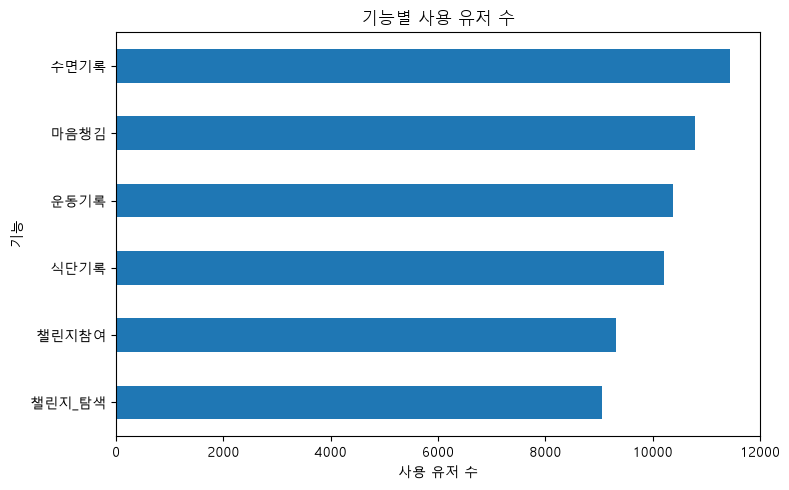

In [20]:
plot_df = feature_summary.sort_values("user_count", ascending=True)

ax = plot_df.plot(
    x="event_type",
    y="user_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("기능별 사용 유저 수")
plt.xlabel("사용 유저 수")
plt.ylabel("기능")
plt.tight_layout()
plt.show()

In [11]:
# 월별 세부 기능 사용률 시각화

# 알림 제외 앱 내 활성 이벤트
app_activity_base = event_base[
    ~event_base["event_type"].isin(["알림수신", "알림오픈"])
].copy()

# 월별 앱 내 활성 유저 수
monthly_app_active_users = (
    app_activity_base
    .groupby("event_month")["user_id"]
    .nunique()
    .reset_index(name="monthly_app_active_users")
)

# 월별 기능별 사용 유저 수
monthly_feature_usage = (
    feature_base
    .groupby(["event_month", "event_type"])
    .agg(
        event_count=("event_type", "count"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

monthly_feature_usage = monthly_feature_usage.merge(
    monthly_app_active_users,
    on="event_month",
    how="left"
)

monthly_feature_usage["feature_user_rate"] = (
    monthly_feature_usage["user_count"] /
    monthly_feature_usage["monthly_app_active_users"]
).round(4)

display(monthly_feature_usage)

,event_month,event_type,event_count,user_count,monthly_app_active_users,feature_user_rate
0,2025-01,마음챙김,8255,1778,2124,0.8371
1,2025-01,수면기록,15041,1915,2124,0.9016
2,2025-01,식단기록,6448,1644,2124,0.7740
3,2025-01,운동기록,8145,1695,2124,0.7980
4,2025-01,챌린지_탐색,8195,1475,2124,0.6944
5,2025-01,챌린지참여,10018,1524,2124,0.7175
6,2025-02,마음챙김,24404,4494,5264,0.8537
7,2025-02,수면기록,44972,4821,5264,0.9158
8,2025-02,식단기록,18845,4291,5264,0.8152
9,2025-02,운동기록,24399,4295,5264,0.8159


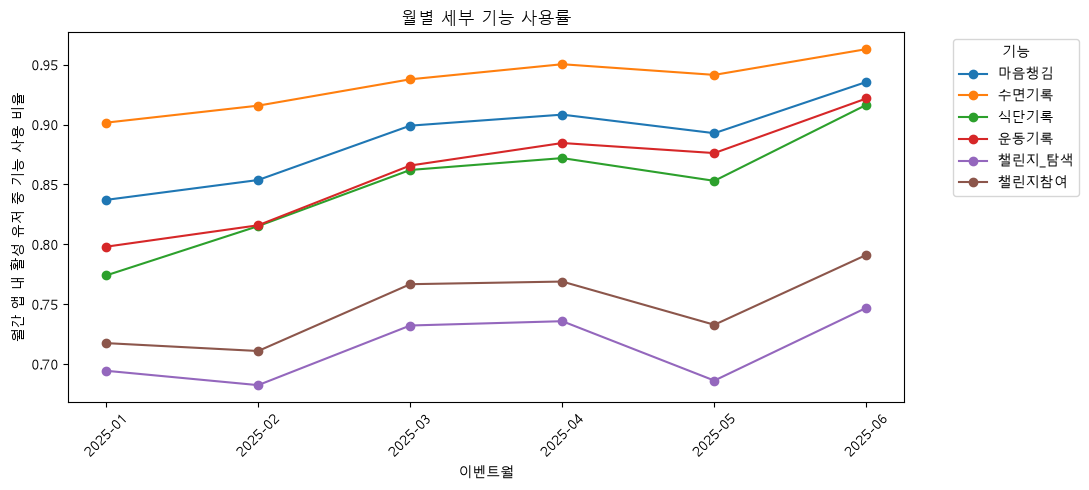

In [12]:
pivot_feature_rate = monthly_feature_usage.pivot(
    index="event_month",
    columns="event_type",
    values="feature_user_rate"
)

ax = pivot_feature_rate.plot(
    marker="o",
    figsize=(11, 5)
)

plt.title("월별 세부 기능 사용률")
plt.xlabel("이벤트월")
plt.ylabel("월간 앱 내 활성 유저 중 기능 사용 비율")
plt.xticks(rotation=45)
plt.legend(title="기능", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
# 기능별 반복 사용률

user_feature_count = (
    feature_base
    .groupby(["user_id", "event_type"])
    .size()
    .reset_index(name="use_count")
)

repeat_summary = (
    user_feature_count
    .groupby("event_type")
    .agg(
        user_count=("user_id", "nunique"),
        avg_use_count=("use_count", "mean"),
        median_use_count=("use_count", "median"),
        users_3plus=("use_count", lambda x: (x >= 3).sum()),
        users_5plus=("use_count", lambda x: (x >= 5).sum())
    )
    .reset_index()
)

repeat_summary["repeat_3plus_rate"] = (
    repeat_summary["users_3plus"] /
    repeat_summary["user_count"]
).round(4)

repeat_summary["repeat_5plus_rate"] = (
    repeat_summary["users_5plus"] /
    repeat_summary["user_count"]
).round(4)

repeat_summary = repeat_summary.sort_values(
    "repeat_3plus_rate",
    ascending=False
)

display(repeat_summary)

,event_type,user_count,avg_use_count,median_use_count,users_3plus,users_5plus,repeat_3plus_rate,repeat_5plus_rate
1,수면기록,11432,21.004724,8.0,9024,7327,0.7894,0.6409
0,마음챙김,10795,11.927466,5.0,7595,5767,0.7036,0.5342
3,운동기록,10374,12.505109,5.0,7130,5410,0.6873,0.5215
2,식단기록,10217,9.798375,5.0,6798,5125,0.6654,0.5016
5,챌린지참여,9321,10.277974,5.0,6083,4807,0.6526,0.5157
4,챌린지_탐색,9055,8.532303,4.0,5640,4320,0.6229,0.4771


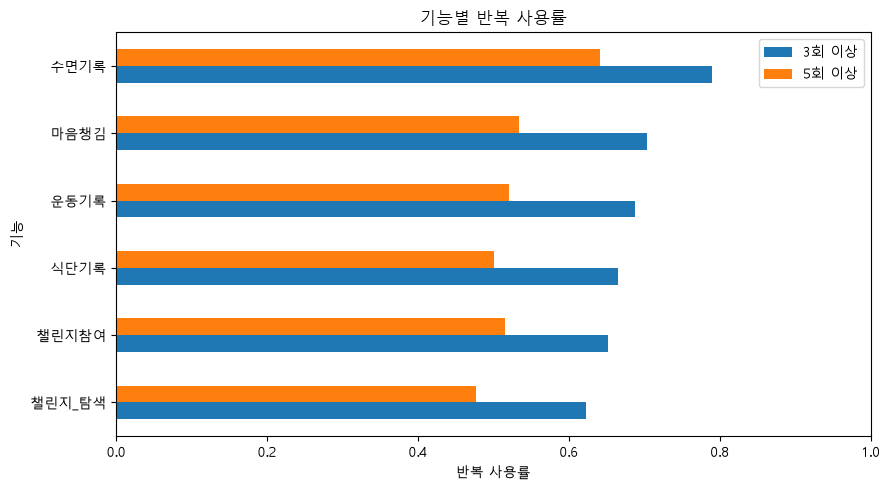

In [14]:
repeat_plot = repeat_summary.sort_values(
    "repeat_3plus_rate",
    ascending=True
)

ax = repeat_plot.plot(
    x="event_type",
    y=["repeat_3plus_rate", "repeat_5plus_rate"],
    kind="barh",
    figsize=(9, 5)
)

plt.title("기능별 반복 사용률")
plt.xlabel("반복 사용률")
plt.ylabel("기능")
plt.legend(["3회 이상", "5회 이상"])
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

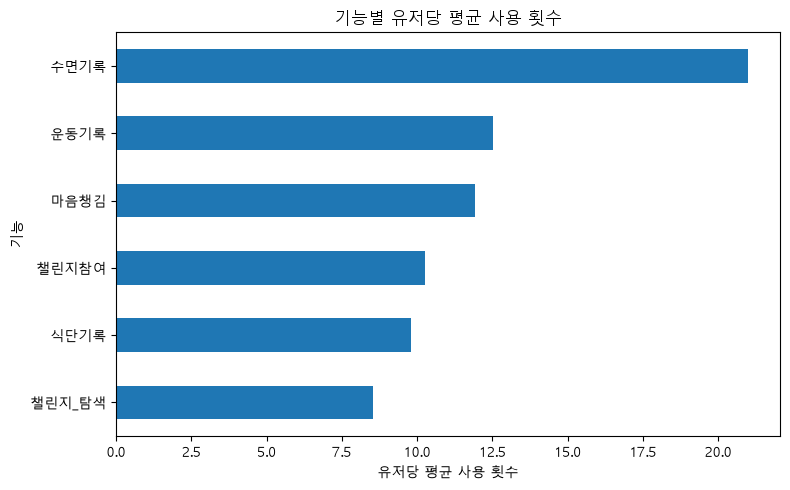

In [15]:
avg_plot = repeat_summary.sort_values(
    "avg_use_count",
    ascending=True
)

ax = avg_plot.plot(
    x="event_type",
    y="avg_use_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("기능별 유저당 평균 사용 횟수")
plt.xlabel("유저당 평균 사용 횟수")
plt.ylabel("기능")
plt.tight_layout()
plt.show()

In [16]:
# 챌린지 탐색 -> 참여 전환율

challenge_events = event_base[
    event_base["event_type"].isin(["챌린지_탐색", "챌린지참여"])
].copy()

explore_users = set(
    challenge_events.loc[
        challenge_events["event_type"] == "챌린지_탐색",
        "user_id"
    ]
)

join_users = set(
    challenge_events.loc[
        challenge_events["event_type"] == "챌린지참여",
        "user_id"
    ]
)

explore_and_join_users = explore_users & join_users
join_without_explore_users = join_users - explore_users

challenge_summary = pd.DataFrame({
    "탐색유저수": [len(explore_users)],
    "참여유저수": [len(join_users)],
    "탐색후_참여유저수": [len(explore_and_join_users)],
    "탐색없이_참여유저수": [len(join_without_explore_users)]
})

challenge_summary["탐색유저_기준_참여전환율"] = (
    challenge_summary["탐색후_참여유저수"] /
    challenge_summary["탐색유저수"]
).round(4)

challenge_summary["참여유저_중_탐색없이참여비율"] = (
    challenge_summary["탐색없이_참여유저수"] /
    challenge_summary["참여유저수"]
).round(4)

display(challenge_summary)


,탐색유저수,참여유저수,탐색후_참여유저수,탐색없이_참여유저수,탐색유저_기준_참여전환율,참여유저_중_탐색없이참여비율
0,9055,9321,9033,288,0.9976,0.0309


In [17]:
# 월별 기준

challenge_monthly_user = (
    challenge_events
    .assign(used=1)
    .pivot_table(
        index=["event_month", "user_id"],
        columns="event_type",
        values="used",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

for col in ["챌린지_탐색", "챌린지참여"]:
    if col not in challenge_monthly_user.columns:
        challenge_monthly_user[col] = 0

challenge_monthly_user["탐색후_참여"] = (
    (challenge_monthly_user["챌린지_탐색"] == 1) &
    (challenge_monthly_user["챌린지참여"] == 1)
)

challenge_monthly_user["탐색없이_참여"] = (
    (challenge_monthly_user["챌린지_탐색"] == 0) &
    (challenge_monthly_user["챌린지참여"] == 1)
)

challenge_monthly_summary = (
    challenge_monthly_user
    .groupby("event_month")
    .agg(
        탐색유저수=("챌린지_탐색", "sum"),
        참여유저수=("챌린지참여", "sum"),
        탐색후_참여유저수=("탐색후_참여", "sum"),
        탐색없이_참여유저수=("탐색없이_참여", "sum")
    )
    .reset_index()
)

challenge_monthly_summary["탐색유저_기준_참여전환율"] = (
    challenge_monthly_summary["탐색후_참여유저수"] /
    challenge_monthly_summary["탐색유저수"]
).round(4)

challenge_monthly_summary["참여유저_중_탐색없이참여비율"] = (
    challenge_monthly_summary["탐색없이_참여유저수"] /
    challenge_monthly_summary["참여유저수"]
).round(4)

display(challenge_monthly_summary)

,event_month,탐색유저수,참여유저수,탐색후_참여유저수,탐색없이_참여유저수,탐색유저_기준_참여전환율,참여유저_중_탐색없이참여비율
0,2025-01,1475,1524,1470,54,0.9966,0.0354
1,2025-02,3592,3742,3576,166,0.9955,0.0444
2,2025-03,3600,3770,3587,183,0.9964,0.0485
3,2025-04,3890,4065,3875,190,0.9961,0.0467
4,2025-05,3426,3659,3414,245,0.9965,0.0670
5,2025-06,1252,1326,1248,78,0.9968,0.0588


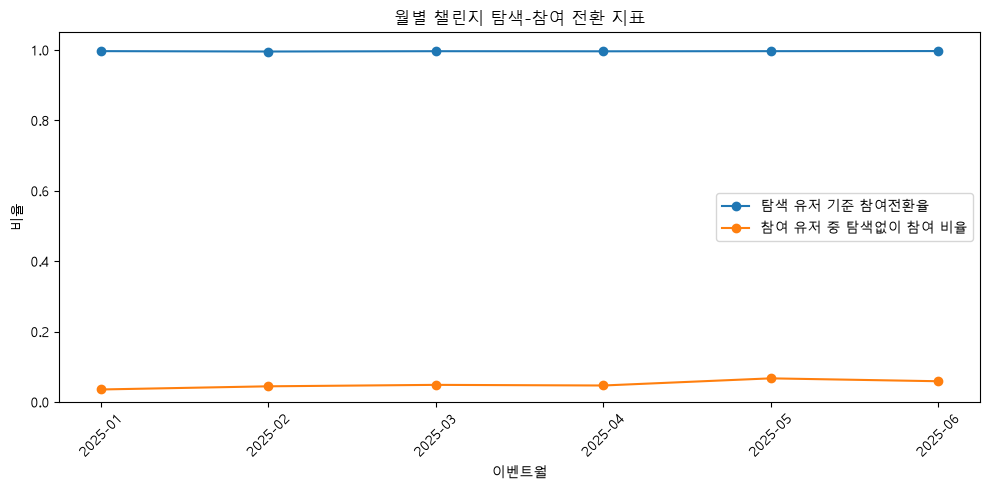

In [18]:
plot_df = challenge_monthly_summary.copy()

ax = plot_df.plot(
    x="event_month",
    y=["탐색유저_기준_참여전환율", "참여유저_중_탐색없이참여비율"],
    marker="o",
    figsize=(10, 5)
)

plt.title("월별 챌린지 탐색-참여 전환 지표")
plt.xlabel("이벤트월")
plt.ylabel("비율")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.legend(["탐색 유저 기준 참여전환율", "참여 유저 중 탐색없이 참여 비율"])
plt.tight_layout()
plt.show()

In [19]:
first_explore = (
    challenge_events[challenge_events["event_type"] == "챌린지_탐색"]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_explore_time")
)

first_join = (
    challenge_events[challenge_events["event_type"] == "챌린지참여"]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_join_time")
)

challenge_sequence = first_explore.merge(
    first_join,
    on="user_id",
    how="outer"
)

challenge_sequence["has_explore"] = challenge_sequence["first_explore_time"].notna()
challenge_sequence["has_join"] = challenge_sequence["first_join_time"].notna()

challenge_sequence["explore_before_join"] = (
    challenge_sequence["has_explore"] &
    challenge_sequence["has_join"] &
    (challenge_sequence["first_explore_time"] <= challenge_sequence["first_join_time"])
)

challenge_sequence["join_without_explore"] = (
    (~challenge_sequence["has_explore"]) &
    challenge_sequence["has_join"]
)

challenge_sequence_summary = pd.DataFrame({
    "탐색유저수": [challenge_sequence["has_explore"].sum()],
    "참여유저수": [challenge_sequence["has_join"].sum()],
    "시간순_탐색후참여유저수": [challenge_sequence["explore_before_join"].sum()],
    "탐색없이_참여유저수": [challenge_sequence["join_without_explore"].sum()]
})

challenge_sequence_summary["시간순_탐색후참여율"] = (
    challenge_sequence_summary["시간순_탐색후참여유저수"] /
    challenge_sequence_summary["탐색유저수"]
).round(4)

challenge_sequence_summary["참여유저_중_탐색없이참여비율"] = (
    challenge_sequence_summary["탐색없이_참여유저수"] /
    challenge_sequence_summary["참여유저수"]
).round(4)

display(challenge_sequence_summary)

,탐색유저수,참여유저수,시간순_탐색후참여유저수,탐색없이_참여유저수,시간순_탐색후참여율,참여유저_중_탐색없이참여비율
0,9055,9321,7912,288,0.8738,0.0309


### 첫 사용 기능 분석

In [21]:
user_base = user_df.copy()

# 유저별 첫 핵심 기능
first_feature = (
    feature_base
    .sort_values(["user_id", "event_time"])
    .groupby("user_id")
    .first()
    .reset_index()[["user_id", "event_type", "event_time"]]
    .rename(columns={
        "event_type": "first_feature",
        "event_time": "first_feature_time"
    })
)

first_feature_summary = (
    first_feature
    .groupby("first_feature")
    .agg(user_count=("user_id", "nunique"))
    .reset_index()
)

first_feature_summary["user_rate"] = (
    first_feature_summary["user_count"] /
    first_feature["user_id"].nunique()
).round(4)

first_feature_summary = first_feature_summary.sort_values(
    "user_count",
    ascending=False
)

display(first_feature_summary)

,first_feature,user_count,user_rate
1,수면기록,5444,0.4455
3,운동기록,1955,0.1600
0,마음챙김,1819,0.1489
4,챌린지_탐색,1612,0.1319
2,식단기록,1123,0.0919
5,챌린지참여,266,0.0218


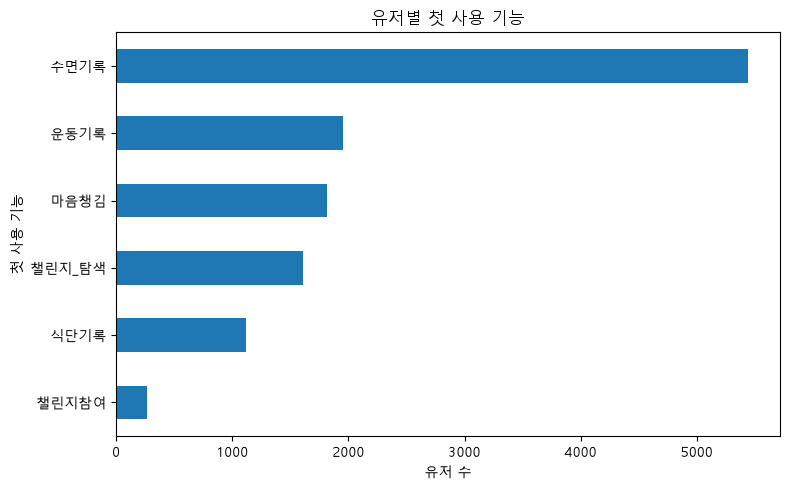

In [22]:
plot_df = first_feature_summary.sort_values("user_count", ascending=True)

ax = plot_df.plot(
    x="first_feature",
    y="user_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("유저별 첫 사용 기능")
plt.xlabel("유저 수")
plt.ylabel("첫 사용 기능")
plt.tight_layout()
plt.show()

In [23]:
# 유저별 기능 사용량
user_feature_depth = (
    feature_base
    .groupby("user_id")
    .agg(
        total_feature_events=("event_type", "count"),
        feature_kind_count=("event_type", "nunique")
    )
    .reset_index()
)

first_feature_depth = first_feature.merge(
    user_feature_depth,
    on="user_id",
    how="left"
)

first_feature_depth_summary = (
    first_feature_depth
    .groupby("first_feature")
    .agg(
        users=("user_id", "nunique"),
        avg_total_feature_events=("total_feature_events", "mean"),
        avg_feature_kind_count=("feature_kind_count", "mean")
    )
    .reset_index()
)

display(first_feature_depth_summary)

,first_feature,users,avg_total_feature_events,avg_feature_kind_count
0,마음챙김,1819,54.007147,4.892798
1,수면기록,5444,63.658707,4.934607
2,식단기록,1123,55.225289,4.885129
3,운동기록,1955,60.194373,5.040409
4,챌린지_탐색,1612,77.173077,5.374069
5,챌린지참여,266,86.030075,5.364662


In [24]:
# 유저 x 기능 사용 여부 매트릭스
user_feature_matrix = (
    feature_base
    .assign(used=1)
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="used",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

# 없는 컬럼 방어
for col in feature_events:
    if col not in user_feature_matrix.columns:
        user_feature_matrix[col] = 0

# 사용한 기능 개수
user_feature_matrix["feature_kind_count"] = (
    user_feature_matrix[feature_events].sum(axis=1)
)

# 기능 조합 문자열
user_feature_matrix["feature_combination"] = user_feature_matrix[feature_events].apply(
    lambda row: " + ".join([col for col in feature_events if row[col] == 1]),
    axis=1
)

combination_summary = (
    user_feature_matrix
    .groupby("feature_combination")
    .agg(user_count=("user_id", "nunique"))
    .reset_index()
    .sort_values("user_count", ascending=False)
)

combination_summary["user_rate"] = (
    combination_summary["user_count"] /
    user_feature_matrix["user_id"].nunique()
).round(4)

display(combination_summary.head(15))

,feature_combination,user_count,user_rate
5,마음챙김 + 수면기록 + 식단기록 + 운동기록 + 챌린지_탐색 + 챌린지참여,7351,0.6016
3,마음챙김 + 수면기록 + 식단기록 + 운동기록,1191,0.0975
12,마음챙김 + 수면기록 + 운동기록 + 챌린지_탐색 + 챌린지참여,380,0.0311
2,마음챙김 + 수면기록 + 식단기록,287,0.0235
8,마음챙김 + 수면기록 + 식단기록 + 챌린지_탐색 + 챌린지참여,283,0.0232
10,마음챙김 + 수면기록 + 운동기록,273,0.0223
1,마음챙김 + 수면기록,194,0.0159
33,수면기록 + 식단기록 + 운동기록 + 챌린지_탐색 + 챌린지참여,193,0.0158
6,마음챙김 + 수면기록 + 식단기록 + 운동기록 + 챌린지참여,187,0.0153
29,수면기록,183,0.0150


In [25]:
feature_kind_summary = (
    user_feature_matrix
    .groupby("feature_kind_count")
    .agg(user_count=("user_id", "nunique"))
    .reset_index()
)

feature_kind_summary["user_rate"] = (
    feature_kind_summary["user_count"] /
    user_feature_matrix["user_id"].nunique()
).round(4)

display(feature_kind_summary)

,feature_kind_count,user_count,user_rate
0,1,392,0.0321
1,2,642,0.0525
2,3,1032,0.0845
3,4,1694,0.1386
4,5,1108,0.0907
5,6,7351,0.6016


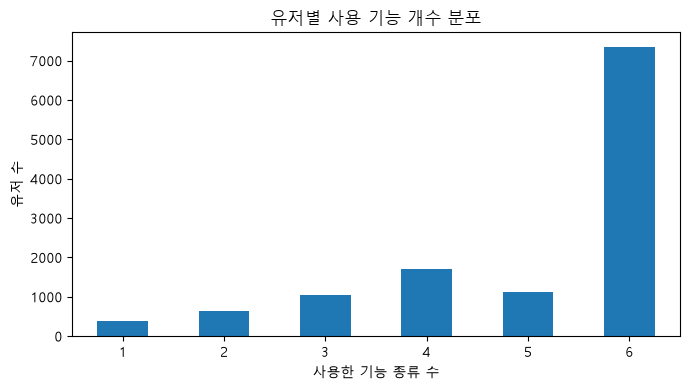

In [26]:
ax = feature_kind_summary.plot(
    x="feature_kind_count",
    y="user_count",
    kind="bar",
    figsize=(7, 4),
    legend=False
)

plt.title("유저별 사용 기능 개수 분포")
plt.xlabel("사용한 기능 종류 수")
plt.ylabel("유저 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 기능 사용 깊이별 세그먼트

In [27]:
# 유저별 기능별 사용 횟수
user_feature_count = (
    feature_base
    .groupby(["user_id", "event_type"])
    .size()
    .reset_index(name="use_count")
)

user_feature_wide = (
    user_feature_count
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="use_count",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

for col in feature_events:
    if col not in user_feature_wide.columns:
        user_feature_wide[col] = 0

# 유저 단위 지표
user_feature_wide["total_feature_events"] = user_feature_wide[feature_events].sum(axis=1)
user_feature_wide["feature_kind_count"] = (user_feature_wide[feature_events] > 0).sum(axis=1)
user_feature_wide["repeat_3plus_feature_count"] = (user_feature_wide[feature_events] >= 3).sum(axis=1)
user_feature_wide["repeat_5plus_feature_count"] = (user_feature_wide[feature_events] >= 5).sum(axis=1)

# 기록 기능 합계
record_features = ["수면기록", "식단기록", "운동기록"]

user_feature_wide["record_total_count"] = user_feature_wide[record_features].sum(axis=1)
user_feature_wide["record_repeat_feature_count"] = (
    user_feature_wide[record_features] >= 3
).sum(axis=1)

In [35]:
def classify_feature_segment(row):
    if row["total_feature_events"] <= 5:
        return "저관여 기능 사용자"
    
    if row["repeat_5plus_feature_count"] >= 4:
        return "고관여 멀티기능 사용자"
    
    if row["수면기록"] >= 10 and row["record_repeat_feature_count"] >= 2:
        return "수면·기록 습관형"
    
    if row["챌린지참여"] >= 5:
        return "챌린지 참여형"
    
    if row["마음챙김"] >= 5:
        return "마음관리 반복형"
    
    if row["record_repeat_feature_count"] >= 2:
        return "기록 중심 반복형"
    
    return "기타 기능 사용자"

user_feature_wide["feature_segment"] = user_feature_wide.apply(
    classify_feature_segment,
    axis=1
)

segment_summary = (
    user_feature_wide
    .groupby("feature_segment")
    .agg(
        user_count=("user_id", "nunique"),
        avg_total_feature_events=("total_feature_events", "mean"),
        avg_feature_kind_count=("feature_kind_count", "mean"),
        avg_repeat_5plus_feature_count=("repeat_5plus_feature_count", "mean")
    )
    .reset_index()
)

segment_summary["user_rate"] = (
    segment_summary["user_count"] /
    user_feature_wide["user_id"].nunique()
).round(4)

segment_summary_v2 = segment_summary.sort_values("user_count", ascending=False)

display(segment_summary)

,feature_segment,user_count,avg_total_feature_events,avg_feature_kind_count,avg_repeat_5plus_feature_count,user_rate
0,고관여 멀티기능 사용자,4996,135.795637,5.979784,5.421938,0.4089
1,기록 중심 반복형,1234,15.739870,5.003241,0.929498,0.1010
2,기타 기능 사용자,2161,9.429894,4.578899,0.206386,0.1769
3,마음관리 반복형,649,20.232666,5.325116,2.030817,0.0531
4,수면·기록 습관형,563,30.808171,5.522202,2.197158,0.0461
5,저관여 기능 사용자,1931,3.145003,2.497670,0.000000,0.1580
6,챌린지 참여형,685,24.813139,5.637956,2.218978,0.0561


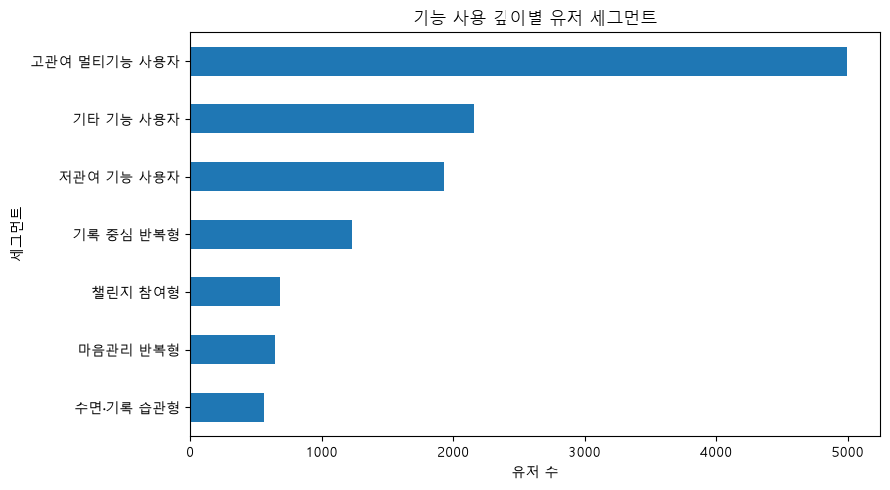

In [36]:
plot_df = segment_summary.sort_values("user_count", ascending=True)

ax = plot_df.plot(
    x="feature_segment",
    y="user_count",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

plt.title("기능 사용 깊이별 유저 세그먼트")
plt.xlabel("유저 수")
plt.ylabel("세그먼트")
plt.tight_layout()
plt.show()

### 수면기록을 사용한 유저는 이후 다른 기능으로 확ㅈㅇ되는가

In [37]:

# 유저별 첫 수면기록 시간
first_sleep = (
    feature_base[feature_base["event_type"] == "수면기록"]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_sleep_time")
)

print("수면기록 경험 유저 수:", first_sleep["user_id"].nunique())
display(first_sleep.head())

수면기록 경험 유저 수: 11432


,user_id,first_sleep_time
0,U0000001,2025-01-27 09:52:47
1,U0000002,2025-05-08 15:57:39
2,U0000003,2025-05-14 11:10:28
3,U0000004,2025-02-28 07:07:13
4,U0000005,2025-02-19 16:13:01


In [38]:
# 첫 수면기록 이후 다른 기능 사용 여부

# 첫 수면기록 시간 붙이기
sleep_after_events = feature_base.merge(
    first_sleep,
    on="user_id",
    how="inner"
)

# 첫 수면기록 이후 이벤트만 필터링
sleep_after_events = sleep_after_events[
    sleep_after_events["event_time"] > sleep_after_events["first_sleep_time"]
].copy()

# 수면기록 이후 사용한 기능 중 수면기록 제외
after_sleep_other_features = sleep_after_events[
    sleep_after_events["event_type"] != "수면기록"
].copy()

# 유저별 수면기록 이후 확장 기능 수
sleep_expansion_user = (
    after_sleep_other_features
    .groupby("user_id")
    .agg(
        after_sleep_feature_count=("event_type", "nunique"),
        after_sleep_event_count=("event_type", "count")
    )
    .reset_index()
)

# 전체 수면기록 유저 기준으로 붙이기
sleep_expansion_user = first_sleep.merge(
    sleep_expansion_user,
    on="user_id",
    how="left"
)

sleep_expansion_user["after_sleep_feature_count"] = (
    sleep_expansion_user["after_sleep_feature_count"].fillna(0).astype(int)
)

sleep_expansion_user["after_sleep_event_count"] = (
    sleep_expansion_user["after_sleep_event_count"].fillna(0).astype(int)
)

sleep_expansion_user["expanded_after_sleep"] = (
    sleep_expansion_user["after_sleep_feature_count"] > 0
)

sleep_expansion_summary = pd.DataFrame({
    "수면기록_유저수": [sleep_expansion_user["user_id"].nunique()],
    "수면이후_타기능확장_유저수": [sleep_expansion_user["expanded_after_sleep"].sum()]
})

sleep_expansion_summary["수면이후_타기능확장률"] = (
    sleep_expansion_summary["수면이후_타기능확장_유저수"] /
    sleep_expansion_summary["수면기록_유저수"]
).round(4)

display(sleep_expansion_summary)

,수면기록_유저수,수면이후_타기능확장_유저수,수면이후_타기능확장률
0,11432,11034,0.9652


In [39]:
# 수면 기록 이후 어떤 기능으로 확ㅈㅇ되는지

after_sleep_feature_summary = (
    after_sleep_other_features
    .groupby("event_type")
    .agg(
        user_count=("user_id", "nunique"),
        event_count=("event_type", "count")
    )
    .reset_index()
)

after_sleep_feature_summary["수면기록유저_대비_확장률"] = (
    after_sleep_feature_summary["user_count"] /
    first_sleep["user_id"].nunique()
).round(4)

after_sleep_feature_summary = after_sleep_feature_summary.sort_values(
    "user_count",
    ascending=False
)

display(after_sleep_feature_summary)

,event_type,user_count,event_count,수면기록유저_대비_확장률
0,마음챙김,9930,123787,0.8686
2,운동기록,9543,125132,0.8348
1,식단기록,9436,96357,0.8254
4,챌린지참여,8357,88910,0.7310
3,챌린지_탐색,8056,71357,0.7047


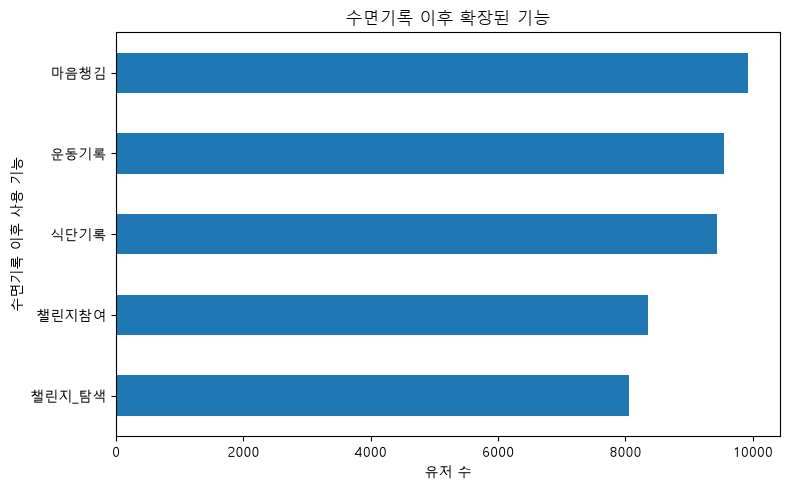

In [40]:
plot_df = after_sleep_feature_summary.sort_values("user_count", ascending=True)

ax = plot_df.plot(
    x="event_type",
    y="user_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("수면기록 이후 확장된 기능")
plt.xlabel("유저 수")
plt.ylabel("수면기록 이후 사용 기능")
plt.tight_layout()
plt.show()

In [41]:
# 수면 기록 직후 바로 이어진 다음 기능

# 첫 수면기록 이후 첫 번째로 발생한 다른 기능
next_feature_after_sleep = (
    after_sleep_other_features
    .sort_values(["user_id", "event_time"])
    .groupby("user_id")
    .first()
    .reset_index()[["user_id", "event_type", "event_time"]]
    .rename(columns={
        "event_type": "next_feature_after_sleep",
        "event_time": "next_feature_time"
    })
)

next_feature_summary = (
    next_feature_after_sleep
    .groupby("next_feature_after_sleep")
    .agg(user_count=("user_id", "nunique"))
    .reset_index()
)

next_feature_summary["user_rate"] = (
    next_feature_summary["user_count"] /
    first_sleep["user_id"].nunique()
).round(4)

next_feature_summary = next_feature_summary.sort_values(
    "user_count",
    ascending=False
)

display(next_feature_summary)

,next_feature_after_sleep,user_count,user_rate
0,마음챙김,3304,0.2890
2,운동기록,3291,0.2879
1,식단기록,2055,0.1798
3,챌린지_탐색,2021,0.1768
4,챌린지참여,363,0.0318


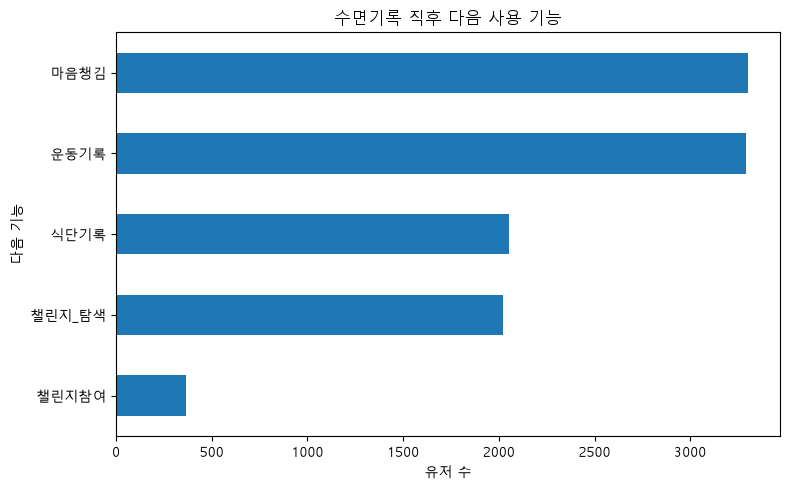

In [42]:
plot_df = next_feature_summary.sort_values("user_count", ascending=True)

ax = plot_df.plot(
    x="next_feature_after_sleep",
    y="user_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("수면기록 직후 다음 사용 기능")
plt.xlabel("유저 수")
plt.ylabel("다음 기능")
plt.tight_layout()
plt.show()

In [43]:
sleep_expansion_user["sleep_user_type"] = np.where(
    sleep_expansion_user["expanded_after_sleep"],
    "수면기록 이후 확장형",
    "수면기록 단독/미확장형"
)

sleep_user_type_summary = (
    sleep_expansion_user
    .groupby("sleep_user_type")
    .agg(
        user_count=("user_id", "nunique"),
        avg_after_sleep_feature_count=("after_sleep_feature_count", "mean"),
        avg_after_sleep_event_count=("after_sleep_event_count", "mean")
    )
    .reset_index()
)

sleep_user_type_summary["user_rate"] = (
    sleep_user_type_summary["user_count"] /
    sleep_expansion_user["user_id"].nunique()
).round(4)

display(sleep_user_type_summary)

,sleep_user_type,user_count,avg_after_sleep_feature_count,avg_after_sleep_event_count,user_rate
0,수면기록 단독/미확장형,398,0.000000,0.000000,0.0348
1,수면기록 이후 확장형,11034,4.107486,45.816839,0.9652


### 수면기록을 한 세션 안에서 바로 다음 기능까지 이어지는지

In [44]:
# session_id 결측 제외
feature_base_session = feature_base[
    feature_base["session_id"].notna()
].copy()

# 수면기록이 포함된 세션
sleep_sessions = (
    feature_base_session[feature_base_session["event_type"] == "수면기록"]
    [["user_id", "session_id"]]
    .drop_duplicates()
)

print("수면기록 포함 세션 수:", len(sleep_sessions))
print("수면기록 포함 유저 수:", sleep_sessions["user_id"].nunique())

수면기록 포함 세션 수: 236622
수면기록 포함 유저 수: 11418


In [45]:
# 같은 세션 내 수면기록 이후 다른 기능 사용 여부

# 세션별 첫 수면기록 시간
first_sleep_in_session = (
    feature_base_session[feature_base_session["event_type"] == "수면기록"]
    .groupby(["user_id", "session_id"])["event_time"]
    .min()
    .reset_index(name="first_sleep_time_in_session")
)

# 첫 수면기록 시간 붙이기
session_after_sleep = feature_base_session.merge(
    first_sleep_in_session,
    on=["user_id", "session_id"],
    how="inner"
)

# 같은 세션 안에서 첫 수면기록 이후 발생한 다른 기능
same_session_after_sleep = session_after_sleep[
    (session_after_sleep["event_time"] > session_after_sleep["first_sleep_time_in_session"]) &
    (session_after_sleep["event_type"] != "수면기록")
].copy()

# 세션 단위 확장 여부
same_session_expansion = (
    first_sleep_in_session
    .merge(
        same_session_after_sleep
        .groupby(["user_id", "session_id"])
        .agg(
            after_sleep_feature_count=("event_type", "nunique"),
            after_sleep_event_count=("event_type", "count")
        )
        .reset_index(),
        on=["user_id", "session_id"],
        how="left"
    )
)

same_session_expansion["after_sleep_feature_count"] = (
    same_session_expansion["after_sleep_feature_count"].fillna(0).astype(int)
)

same_session_expansion["after_sleep_event_count"] = (
    same_session_expansion["after_sleep_event_count"].fillna(0).astype(int)
)

same_session_expansion["expanded_in_same_session"] = (
    same_session_expansion["after_sleep_feature_count"] > 0
)

same_session_summary = pd.DataFrame({
    "수면기록_포함_세션수": [len(same_session_expansion)],
    "같은세션_확장_세션수": [same_session_expansion["expanded_in_same_session"].sum()]
})

same_session_summary["같은세션_확장률"] = (
    same_session_summary["같은세션_확장_세션수"] /
    same_session_summary["수면기록_포함_세션수"]
).round(4)

display(same_session_summary)

,수면기록_포함_세션수,같은세션_확장_세션수,같은세션_확장률
0,236622,114803,0.4852


In [46]:
# 같은 세션 안에서 어떤 기능으로 확장됐는지

same_session_feature_summary = (
    same_session_after_sleep
    .groupby("event_type")
    .agg(
        session_count=("session_id", "nunique"),
        user_count=("user_id", "nunique"),
        event_count=("event_type", "count")
    )
    .reset_index()
)

same_session_feature_summary["수면기록세션_대비_확장률"] = (
    same_session_feature_summary["session_count"] /
    len(same_session_expansion)
).round(4)

same_session_feature_summary = same_session_feature_summary.sort_values(
    "session_count",
    ascending=False
)

display(same_session_feature_summary)

,event_type,session_count,user_count,event_count,수면기록세션_대비_확장률
2,운동기록,41293,7551,41293,0.1745
0,마음챙김,40837,7957,40837,0.1726
1,식단기록,31689,7305,31689,0.1339
4,챌린지참여,30120,6601,30120,0.1273
3,챌린지_탐색,24310,6195,24310,0.1027


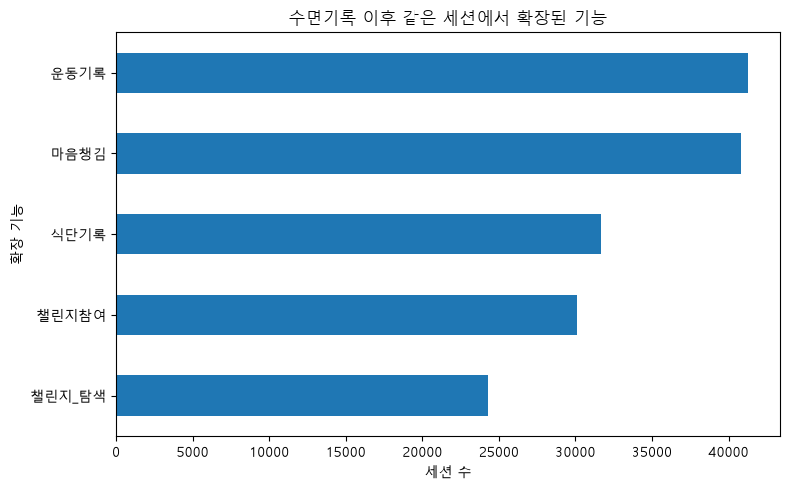

In [47]:
plot_df = same_session_feature_summary.sort_values("session_count", ascending=True)

ax = plot_df.plot(
    x="event_type",
    y="session_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("수면기록 이후 같은 세션에서 확장된 기능")
plt.xlabel("세션 수")
plt.ylabel("확장 기능")
plt.tight_layout()
plt.show()

In [48]:
# 수면기록 직후 같은 세션 내 다음 기능

next_feature_same_session = (
    same_session_after_sleep
    .sort_values(["user_id", "session_id", "event_time"])
    .groupby(["user_id", "session_id"])
    .first()
    .reset_index()[["user_id", "session_id", "event_type", "event_time"]]
    .rename(columns={
        "event_type": "next_feature_same_session",
        "event_time": "next_feature_time"
    })
)

next_same_session_summary = (
    next_feature_same_session
    .groupby("next_feature_same_session")
    .agg(
        session_count=("session_id", "nunique"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

next_same_session_summary["수면기록세션_대비_비율"] = (
    next_same_session_summary["session_count"] /
    len(same_session_expansion)
).round(4)

next_same_session_summary = next_same_session_summary.sort_values(
    "session_count",
    ascending=False
)

display(next_same_session_summary)

,next_feature_same_session,session_count,user_count,수면기록세션_대비_비율
2,운동기록,41267,7548,0.1744
0,마음챙김,33715,7565,0.1425
1,식단기록,21704,6416,0.0917
3,챌린지_탐색,14160,5111,0.0598
4,챌린지참여,3957,2549,0.0167


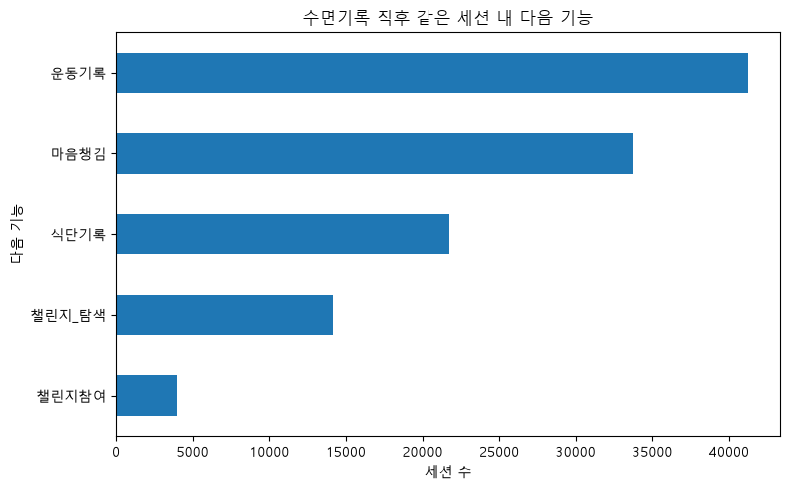

In [49]:
plot_df = next_same_session_summary.sort_values("session_count", ascending=True)

ax = plot_df.plot(
    x="next_feature_same_session",
    y="session_count",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("수면기록 직후 같은 세션 내 다음 기능")
plt.xlabel("세션 수")
plt.ylabel("다음 기능")
plt.tight_layout()
plt.show()

In [50]:
# 유저 단위로 같은 세션 확장 경험 여부

user_same_session_expansion = (
    same_session_expansion
    .groupby("user_id")
    .agg(
        sleep_session_count=("session_id", "nunique"),
        expanded_session_count=("expanded_in_same_session", "sum")
    )
    .reset_index()
)

user_same_session_expansion["has_same_session_expansion"] = (
    user_same_session_expansion["expanded_session_count"] > 0
)

user_same_session_expansion["same_session_expansion_rate_per_user"] = (
    user_same_session_expansion["expanded_session_count"] /
    user_same_session_expansion["sleep_session_count"]
).round(4)

user_same_session_summary = pd.DataFrame({
    "수면기록_유저수": [user_same_session_expansion["user_id"].nunique()],
    "같은세션_확장경험_유저수": [user_same_session_expansion["has_same_session_expansion"].sum()]
})

user_same_session_summary["같은세션_확장경험_유저비율"] = (
    user_same_session_summary["같은세션_확장경험_유저수"] /
    user_same_session_summary["수면기록_유저수"]
).round(4)

display(user_same_session_summary)

,수면기록_유저수,같은세션_확장경험_유저수,같은세션_확장경험_유저비율
0,11418,10205,0.8938


### 기능 사용 시간대

In [30]:
hourly_feature = (
    feature_base
    .groupby(["event_hour", "event_type"])
    .agg(
        event_count=("event_type", "count"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

display(hourly_feature.head())

,event_hour,event_type,event_count,user_count
0,6,마음챙김,5,5
1,6,수면기록,6,6
2,6,식단기록,5,5
3,6,운동기록,3,3
4,6,챌린지_탐색,3,3


In [31]:
hourly_feature["event_type_total"] = (
    hourly_feature
    .groupby("event_type")["event_count"]
    .transform("sum")
)

hourly_feature["hour_share"] = (
    hourly_feature["event_count"] /
    hourly_feature["event_type_total"]
).round(4)

hourly_pivot = hourly_feature.pivot(
    index="event_hour",
    columns="event_type",
    values="hour_share"
).fillna(0)

display(hourly_pivot)

event_type,마음챙김,수면기록,식단기록,운동기록,챌린지_탐색,챌린지참여
event_hour,,,,,,
6,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.0628,0.0623,0.0616,0.0618,0.0598,0.0584
8,0.0625,0.0631,0.0623,0.0640,0.0625,0.0625
9,0.0615,0.0624,0.0607,0.0620,0.0632,0.0629
10,0.0619,0.0617,0.0629,0.0616,0.0630,0.0631
11,0.0625,0.0629,0.0632,0.0624,0.0629,0.0628
12,0.0632,0.0630,0.0626,0.0632,0.0625,0.0630
13,0.0616,0.0625,0.0626,0.0633,0.0632,0.0623
14,0.0631,0.0618,0.0624,0.0640,0.0633,0.0631


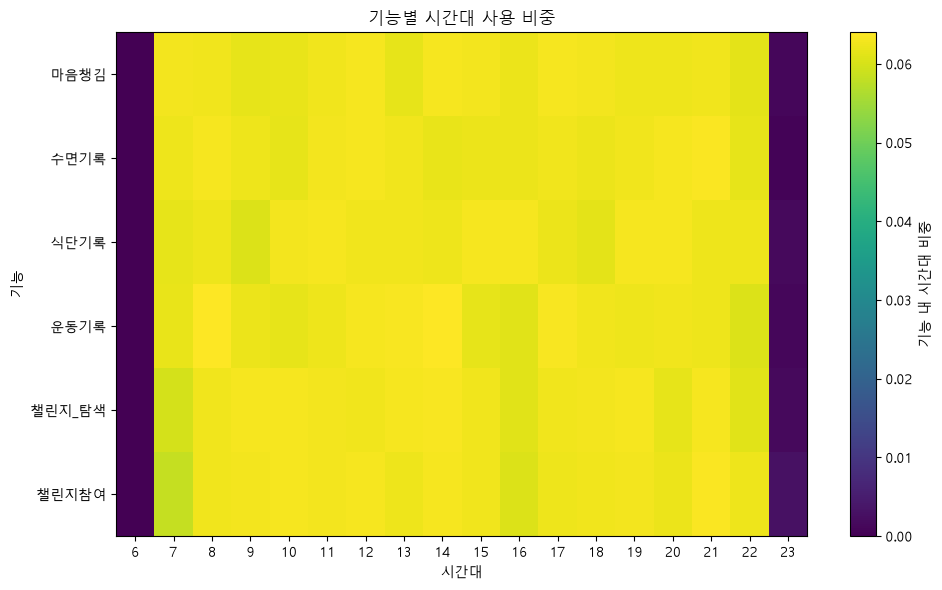

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(hourly_pivot.T, aspect="auto")

ax.set_title("기능별 시간대 사용 비중")
ax.set_xlabel("시간대")
ax.set_ylabel("기능")

ax.set_xticks(range(len(hourly_pivot.index)))
ax.set_xticklabels(hourly_pivot.index)

ax.set_yticks(range(len(hourly_pivot.columns)))
ax.set_yticklabels(hourly_pivot.columns)

plt.colorbar(im, ax=ax, label="기능 내 시간대 비중")
plt.tight_layout()
plt.show()

In [33]:
peak_hour_by_feature = (
    hourly_feature
    .sort_values(["event_type", "event_count"], ascending=[True, False])
    .groupby("event_type")
    .head(3)
    .sort_values(["event_type", "event_count"], ascending=[True, False])
)

display(peak_hour_by_feature)

,event_hour,event_type,event_count,user_count,event_type_total,hour_share
36,12,마음챙김,8143,4411,128757,0.0632
66,17,마음챙김,8127,4298,128757,0.0631
48,14,마음챙김,8119,4330,128757,0.0631
91,21,수면기록,15258,5645,240126,0.0635
13,8,수면기록,15152,5650,240126,0.0631
85,20,수면기록,15146,5611,240126,0.0631
32,11,식단기록,6329,3785,100110,0.0632
56,15,식단기록,6314,3792,100110,0.0631
86,20,식단기록,6311,3766,100110,0.0630
15,8,운동기록,8305,4198,129728,0.0640


---
# 세션 단위 기능 사용 분석


In [52]:
# 세션 ID가 있는 기능 이벤트만 사용
session_feature_base = feature_base[
    feature_base["session_id"].notna()
].copy()

# 혹시 session_id가 유저 간 중복될 수 있으므로 user_id + session_id 조합으로 세션 키 생성
session_feature_base["session_key"] = (
    session_feature_base["user_id"].astype(str)
    + "_"
    + session_feature_base["session_id"].astype(str)
)

print("기능 이벤트 수:", len(session_feature_base))
print("기능 사용 세션 수:", session_feature_base["session_key"].nunique())
print("기능 사용 유저 수:", session_feature_base["user_id"].nunique())

display(
    session_feature_base[["user_id", "session_id", "session_key", "event_time", "event_type"]].head()
)

기능 이벤트 수: 760307
기능 사용 세션 수: 476884
기능 사용 유저 수: 12214


,user_id,session_id,session_key,event_time,event_type
2,U0000001,2858201769,U0000001_2858201769,2025-01-25 07:26:55,챌린지_탐색
3,U0000001,2858201769,U0000001_2858201769,2025-01-25 07:27:55,챌린지참여
6,U0000001,b57046502f,U0000001_b57046502f,2025-01-26 10:52:24,운동기록
7,U0000001,b57046502f,U0000001_b57046502f,2025-01-26 10:53:09,챌린지_탐색
8,U0000001,b57046502f,U0000001_b57046502f,2025-01-26 10:56:06,챌린지참여


In [53]:
# 세션당 사용 기능 개수

# 세션 x 기능 사용 여부 매트릭스
session_feature_matrix = (
    session_feature_base
    .assign(used=1)
    .pivot_table(
        index="session_key",
        columns="event_type",
        values="used",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

# 없는 컬럼 방어
for col in feature_events:
    if col not in session_feature_matrix.columns:
        session_feature_matrix[col] = 0

# 세션당 사용 기능 종류 수
session_feature_matrix["session_feature_count"] = (
    session_feature_matrix[feature_events].sum(axis=1)
)

session_feature_count_summary = (
    session_feature_matrix
    .groupby("session_feature_count")
    .agg(session_count=("session_key", "nunique"))
    .reset_index()
)

session_feature_count_summary["session_rate"] = (
    session_feature_count_summary["session_count"]
    / session_feature_matrix["session_key"].nunique()
).round(4)

display(session_feature_count_summary)

,session_feature_count,session_count,session_rate
0,1,275358,0.5774
1,2,136714,0.2867
2,3,49761,0.1043
3,4,13121,0.0275
4,5,1826,0.0038
5,6,104,0.0002


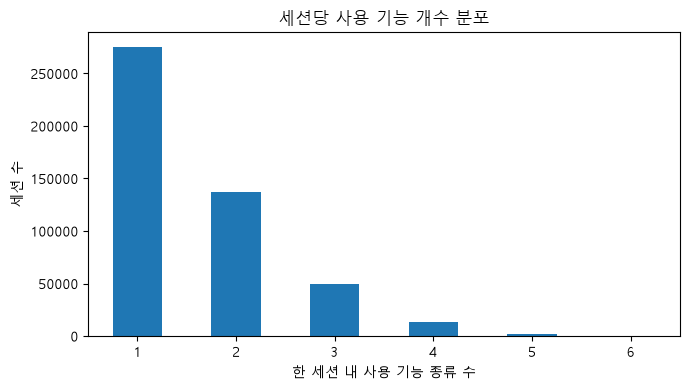

In [54]:
ax = session_feature_count_summary.plot(
    x="session_feature_count",
    y="session_count",
    kind="bar",
    figsize=(7, 4),
    legend=False
)

plt.title("세션당 사용 기능 개수 분포")
plt.xlabel("한 세션 내 사용 기능 종류 수")
plt.ylabel("세션 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
# 세션 내 기능 조합

def make_session_combination(row):
    used_features = [col for col in feature_events if row[col] == 1]
    return " + ".join(used_features)

session_feature_matrix["session_feature_combination"] = (
    session_feature_matrix.apply(make_session_combination, axis=1)
)

session_combination_summary = (
    session_feature_matrix
    .groupby("session_feature_combination")
    .agg(session_count=("session_key", "nunique"))
    .reset_index()
    .sort_values("session_count", ascending=False)
)

session_combination_summary["session_rate"] = (
    session_combination_summary["session_count"]
    / session_feature_matrix["session_key"].nunique()
).round(4)

display(session_combination_summary.head(15))

,session_feature_combination,session_count,session_rate
32,수면기록,121124,0.2540
56,운동기록,52940,0.1110
0,마음챙김,52835,0.1108
48,식단기록,39460,0.0827
61,챌린지_탐색 + 챌린지참여,29171,0.0612
41,수면기록 + 운동기록,25819,0.0541
1,마음챙김 + 수면기록,25370,0.0532
33,수면기록 + 식단기록,19012,0.0399
46,수면기록 + 챌린지_탐색 + 챌린지참여,13770,0.0289
25,마음챙김 + 운동기록,11238,0.0236


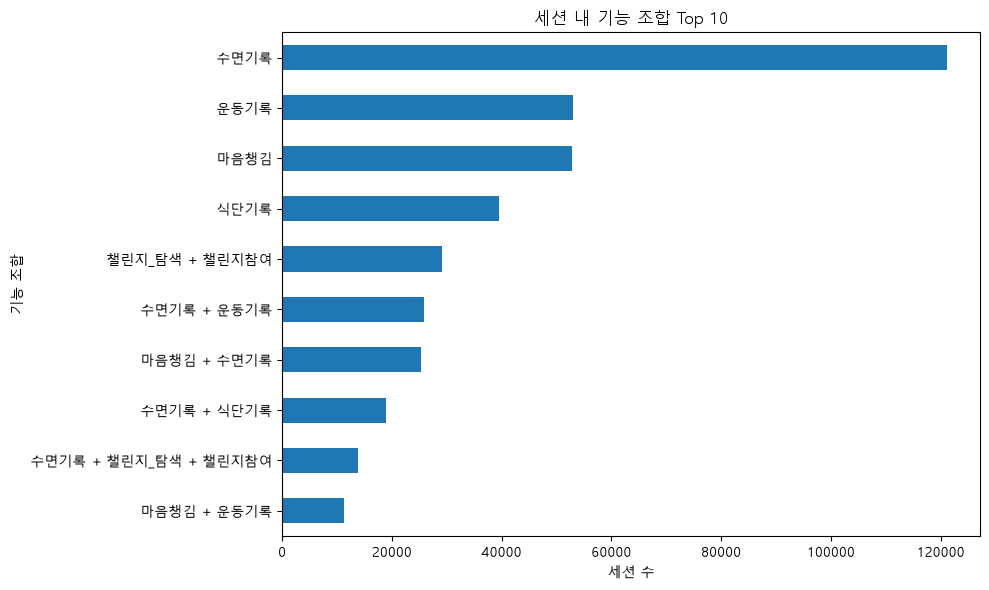

In [56]:
plot_df = session_combination_summary.head(10).sort_values(
    "session_count",
    ascending=True
)

ax = plot_df.plot(
    x="session_feature_combination",
    y="session_count",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("세션 내 기능 조합 Top 10")
plt.xlabel("세션 수")
plt.ylabel("기능 조합")
plt.tight_layout()
plt.show()

---
# 기능별 단독 ㅅ용 vs 함께 사용

In [57]:
feature_solo_co_summary = []

for feature in feature_events:
    # 해당 기능을 사용한 세션
    feature_sessions = session_feature_matrix[
        session_feature_matrix[feature] == 1
    ].copy()
    
    total_sessions = len(feature_sessions)
    
    # 해당 기능만 사용한 세션
    solo_sessions = len(
        feature_sessions[
            feature_sessions["session_feature_count"] == 1
        ]
    )
    
    # 다른 기능과 함께 사용한 세션
    co_use_sessions = len(
        feature_sessions[
            feature_sessions["session_feature_count"] >= 2
        ]
    )
    
    feature_solo_co_summary.append({
        "event_type": feature,
        "feature_session_count": total_sessions,
        "solo_sessions": solo_sessions,
        "co_use_sessions": co_use_sessions,
        "solo_rate": solo_sessions / total_sessions if total_sessions > 0 else np.nan,
        "co_use_rate": co_use_sessions / total_sessions if total_sessions > 0 else np.nan
    })

feature_solo_co_summary = pd.DataFrame(feature_solo_co_summary)

feature_solo_co_summary["solo_rate"] = feature_solo_co_summary["solo_rate"].round(4)
feature_solo_co_summary["co_use_rate"] = feature_solo_co_summary["co_use_rate"].round(4)

feature_solo_co_summary = feature_solo_co_summary.sort_values(
    "co_use_rate",
    ascending=False
)

display(feature_solo_co_summary)

,event_type,feature_session_count,solo_sessions,co_use_sessions,solo_rate,co_use_rate
4,챌린지_탐색,76083,888,75195,0.0117,0.9883
5,챌린지참여,94357,8111,86246,0.0860,0.9140
2,식단기록,98598,39460,59138,0.4002,0.5998
3,운동기록,127779,52940,74839,0.4143,0.5857
0,마음챙김,126868,52835,74033,0.4165,0.5835
1,수면기록,236622,121124,115498,0.5119,0.4881


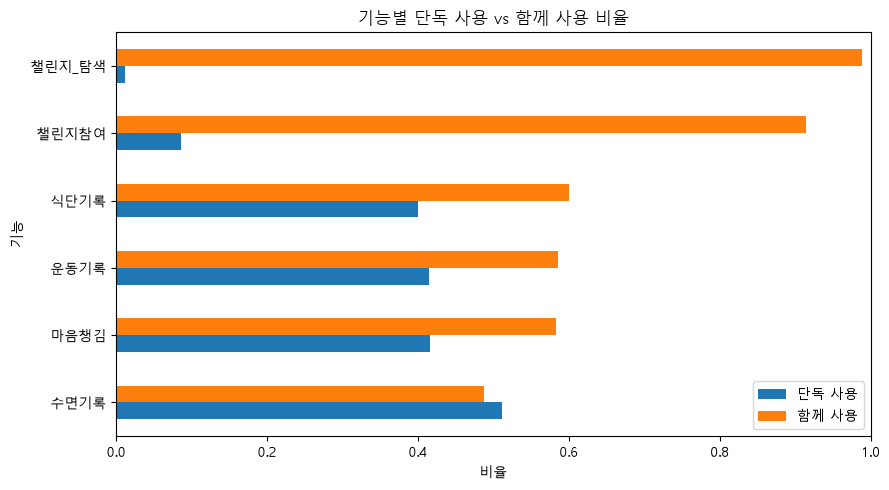

In [58]:
plot_df = feature_solo_co_summary.sort_values("co_use_rate", ascending=True)

ax = plot_df.plot(
    x="event_type",
    y=["solo_rate", "co_use_rate"],
    kind="barh",
    figsize=(9, 5)
)

plt.title("기능별 단독 사용 vs 함께 사용 비율")
plt.xlabel("비율")
plt.ylabel("기능")
plt.legend(["단독 사용", "함께 사용"])
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [60]:
from itertools import combinations

pair_rows = []

for _, row in session_feature_matrix.iterrows():
    used_features = [feature for feature in feature_events if row[feature] == 1]
    
    for f1, f2 in combinations(used_features, 2):
        pair_rows.append({
            "feature_pair": f"{f1} + {f2}"
        })

feature_pair_summary = (
    pd.DataFrame(pair_rows)
    .groupby("feature_pair")
    .agg(session_count=("feature_pair", "count"))
    .reset_index()
    .sort_values("session_count", ascending=False)
)

feature_pair_summary["session_rate"] = (
    feature_pair_summary["session_count"]
    / session_feature_matrix["session_key"].nunique()
).round(4)

display(feature_pair_summary)

,feature_pair,session_count,session_rate
14,챌린지_탐색 + 챌린지참여,73795,0.1547
6,수면기록 + 운동기록,41716,0.0875
0,마음챙김 + 수면기록,41205,0.0864
5,수면기록 + 식단기록,31978,0.0671
8,수면기록 + 챌린지참여,30335,0.0636
7,수면기록 + 챌린지_탐색,24522,0.0514
2,마음챙김 + 운동기록,22375,0.0469
1,마음챙김 + 식단기록,17235,0.0361
13,운동기록 + 챌린지참여,17197,0.0361
9,식단기록 + 운동기록,17130,0.0359


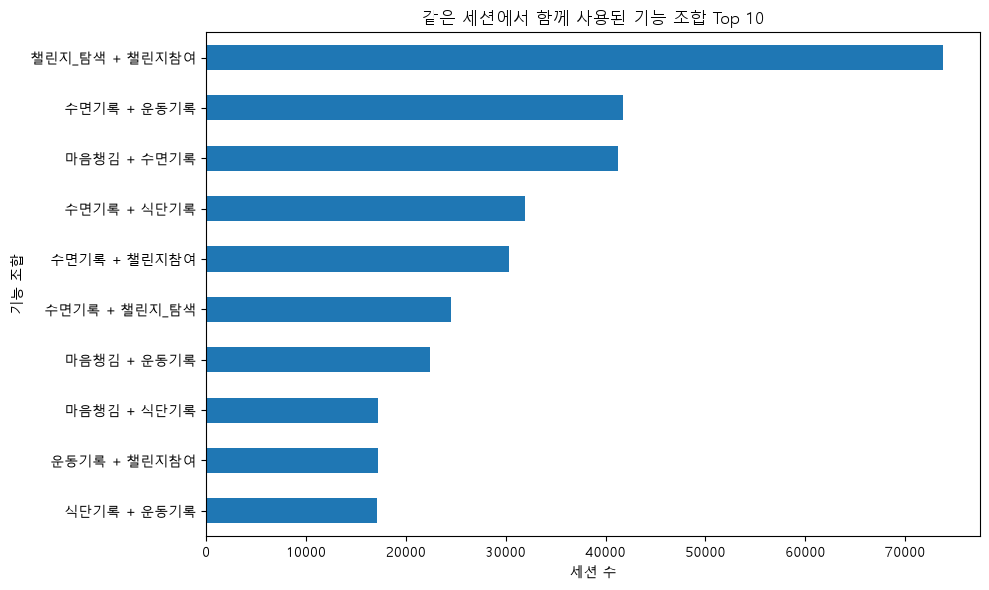

In [61]:
plot_df = feature_pair_summary.head(10).sort_values(
    "session_count",
    ascending=True
)

ax = plot_df.plot(
    x="feature_pair",
    y="session_count",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("같은 세션에서 함께 사용된 기능 조합 Top 10")
plt.xlabel("세션 수")
plt.ylabel("기능 조합")
plt.tight_layout()
plt.show()